# Notebook 3: TF-IDF Doctor Retriever
## Building a Medical Search Engine from Patient Reviews

---

In our Preprocessing notebook, we cleaned **66,465** patient comments into ~52,800 usable rows.

Now we build a **search engine**: given a medical query → return the most relevant doctors.

| Part | Topic |
|------|-------|
| **0** | Setup & Data Loading |
| **1** | TF-IDF Theory (from scratch) |
| **2** | Medical Stopwords Pipeline |
| **3** | Building the Doctor Corpus (baseline + medical) |
| **4** | Building the TF-IDF Index (both variants) |
| **5** | Query Preprocessing |
| **6** | Retrieval — Cosine Similarity Search |
| **7** | Holdout Evaluation (Recall@K, MRR) |
| **8** | Qualitative Test Suite |
| **9** | Interactive Search — Play With the Retriever 🎮 |
| **10** | Summary & Next Steps |

### Two Retriever Variants

| Variant | Stopwords Applied | Best For | Example Queries |
|---------|-------------------|----------|----------------|
| **Baseline** | Standard Persian only (hazm) | Service / behavioral queries | "با حوصله", "بد برخورد" |
| **Medical** | Standard + domain-specific | Clinical / diagnostic queries | "سنگ کلیه", "دیسک کمر" |

The medical variant removes praise ("عالی"), thanks ("ممنون"), clinic ops ("مطب", "نوبت"), and behavioral adjectives ("حوصله", "مهربان") — leaving only **clinical content**.

---
# Part 0: Setup & Data Loading
---

## What is Information Retrieval?

**Information Retrieval (IR)** is the science of finding, within a large collection of unstructured data (usually text), the items that satisfy a user's information need.

```
Google Search:   "kidney stone treatment"   →   Ranked list of web pages
Our System:      "سنگ کلیه"                 →   Ranked list of DOCTORS
```

This is fundamentally different from a database query:

- **Database:** Exact match — `WHERE specialty = 'urology'` returns only urologists, missing doctors whose patients frequently mention kidney stones but whose specialty label is "general surgery".
- **IR:** Semantic relevance — if 50 patients of Dr. X mention "سنگ کلیه" in their reviews, Dr. X is relevant to this query regardless of their listed specialty.

The core idea behind most IR systems: represent both queries and documents as **numerical vectors** in a shared space, then measure the **similarity** between them.

In [92]:
import re, os, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas(desc="Processing")
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print("All imports OK ✓")

All imports OK ✓


## Loading the Data

We load two files produced by our previous notebooks:

1. **Preprocessed comments** — each row is one patient review, already tokenized and cleaned (output of our Preprocessing notebook).
2. **Doctor metadata** — name, specialty, profile URL (from our EDA notebook).

The key column is `final_preprocessed_text`: a space-separated string of tokens, with standard Persian stopwords already removed and Arabic characters normalized to Persian.

In [93]:
# ------------------------------------------------------------
# Part 0 — Data loading sanity + standard columns for NB3
# ------------------------------------------------------------

comments_df = pd.read_csv("comments_for_tfidf_retriever.csv", keep_default_na=False)
comments_df["doctor_id"] = comments_df["doctor_id"].astype(str)

# The preprocessed (tokenized) text from NB2 (space-separated tokens)
comments_df["final_preprocessed_text"] = comments_df["final_preprocessed_text"].astype(str)

# Optional: keep rate numeric for filtering
comments_df["rate_num"] = pd.to_numeric(comments_df.get("rate", np.nan), errors="coerce")

# Optional: remove placeholder negatives if present
if "is_placeholder_negative" in comments_df.columns:
    comments_df["is_placeholder_negative"] = comments_df["is_placeholder_negative"].astype(bool)
    comments_df = comments_df[~comments_df["is_placeholder_negative"]].copy()

# Baseline variant input (already cleaned & tokenized in NB2)
comments_df["text_baseline"] = comments_df["final_preprocessed_text"]

print(f"Loaded {len(comments_df):,} comments | {comments_df['doctor_id'].nunique():,} doctors")
print("Columns ready:", [c for c in ["text_baseline", "rate_num"] if c in comments_df.columns])
comments_df.head(3)

Loaded 63,722 comments | 545 doctors
Columns ready: ['text_baseline', 'rate_num']


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative,rate_num,text_baseline
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False,5.0,حاذق
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False,5.0,زگیل ناخن درمانم
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False,5.0,درود تشخیص درست خارش بدن ودرمان


In [94]:
doctors_df = pd.read_csv("doctors_raw_canonical.csv", keep_default_na=False)
doctors_df["doctor_id"] = doctors_df["doctor_id"].astype(str)
name_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("name", ""))) if "name" in doctors_df.columns else {}
specialty_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("specialty", ""))) if "specialty" in doctors_df.columns else {}
print(f"Loaded {len(doctors_df):,} doctor profiles")

Loaded 569 doctor profiles


---
# Part 1: Understanding TF-IDF (from scratch)
---

**TF-IDF** (Term Frequency – Inverse Document Frequency) is one of the most fundamental and widely-used text representation methods in information retrieval. Despite being introduced in the 1970s, it remains a strong baseline that often outperforms more complex methods on small-to-medium corpora.

In this part, we will:
1. Compute TF-IDF **manually** on a tiny 4-sentence corpus
2. Understand **why** each component exists
3. Verify our manual results match `sklearn`

## 1.1 The Core Problem: Representing Text as Numbers

Machine learning algorithms operate on numbers, not words. We need a function:

$$f: \text{"سنگ کلیه عمل درد"} \longrightarrow [0.42, 0.0, 0.31, \ldots] \in \mathbb{R}^{|V|}$$

where $|V|$ is the vocabulary size. Each dimension corresponds to one word (or phrase), and the value encodes how **important** that word is to this document.

**Example:** Query is "سنگ کلیه" (kidney stones).

| Doctor | Comments | Relevance |
|--------|----------|-----------|
| A | سنگ کلیه عمل درد | ✅ High — shares both query terms |
| B | سنگ مثانه درمان | ⚠️ Partial — shares "سنگ" only |
| C | دکتر خوب عالی | ❌ None — no medical overlap |

TF-IDF is a specific instantiation of this function. Let's build it step by step.

## 1.2 Term Frequency (TF)

The simplest idea: **count how often each word appears** in a document.

$$\text{TF}(t, d) = \text{count of term } t \text{ in document } d$$

If "سنگ" appears 5 times in Doctor A's reviews and 1 time in Doctor B's, Doctor A's document has a higher TF for that term — suggesting stronger association with kidney stones.

In [95]:
# Let's build a tiny corpus and compute TF manually
corpus = [
    "سنگ کلیه درد سنگ",    # Doc 0: kidney stone + pain ("سنگ" appears twice)
    "سنگ مثانه درمان",      # Doc 1: bladder stone treatment
    "دکتر خوب عالی",        # Doc 2: irrelevant praise
    "درد کمر دیسک درد",     # Doc 3: back pain + disc ("درد" appears twice)
]
tokenized = [doc.split() for doc in corpus]
print(tokenized)

[['سنگ', 'کلیه', 'درد', 'سنگ'], ['سنگ', 'مثانه', 'درمان'], ['دکتر', 'خوب', 'عالی'], ['درد', 'کمر', 'دیسک', 'درد']]


In [96]:
# 1. Create an empty set to filter out duplicate words automatically
# 2. Loop through each document (which is a list of words)
# 3. Loop through each word in the current document
# 4. Add the word to the set
# 5. Sort the set alphabetically and convert it to a list

unique_words = set()

for doc in tokenized:
    for w in doc:
        unique_words.add(w)

vocab = sorted(unique_words)
vocab

['خوب', 'درد', 'درمان', 'دکتر', 'دیسک', 'سنگ', 'عالی', 'مثانه', 'کلیه', 'کمر']

In [97]:
vocab[-1]

'کمر'

In [98]:

# 1. Initialize an empty list to hold the rows of our TF matrix
# 2. Loop through each document in the tokenized corpus
# 3. Count the frequency of each word in the current document using 'Counter'
# 4. Initialize an empty list to represent the current row (document vector)
# 5. Loop through every word in our global vocabulary
# 6. Get the frequency of the vocabulary word in the current document (default to 0 if not found)
# 7. Append this frequency to the current row
# 8. Append the completed row to the main TF matrix
# 9. Create an empty list to store the row labels (indexes) for our DataFrame
# 10. Loop through the total number of documents to generate labels
# 11. Append the label (e.g., 'Doc 0', 'Doc 1') to the indices list
# 12. Create the Pandas DataFrame using the matrix, vocabulary as columns, and generated indices
# 13. Print the vocabulary size and the final DataFrame

tf_matrix = []

for doc in tokenized:
    doc_counts = Counter(doc)
    # print(doc_counts)
    # break
    row = []
    
    for t in vocab:
        count = doc_counts.get(t, 0)
        print(count)
    # break
        row.append(count)
        
    tf_matrix.append(row)

# print(tf_matrix)
# print(len(tf_matrix))
doc_indices = []

for i in range(len(corpus)):
    doc_indices.append(f"Doc {i}")


tf_df = pd.DataFrame(tf_matrix, columns=vocab, index=doc_indices)

print(f"Vocabulary ({len(vocab)} unique terms):\n")
tf_df

0
1
0
0
0
2
0
0
1
0
0
0
1
0
0
1
0
1
0
0
1
0
0
1
0
0
1
0
0
0
0
2
0
0
1
0
0
0
0
1
Vocabulary (10 unique terms):



,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0,1,0,0,0,2,0,0,1,0
Doc 1,0,0,1,0,0,1,0,1,0,0
Doc 2,1,0,0,1,0,0,1,0,0,0
Doc 3,0,2,0,0,1,0,0,0,0,1


### The Problem with Raw TF

Raw term frequency has two fundamental weaknesses:

1. **Document length bias:** A doctor with 500 comments will have higher TF for *every* word compared to a doctor with 5 comments — not because they're more relevant, but simply because there's more text.

2. **No discrimination between common and rare words:** The word "درد" (pain) might appear in almost every doctor's reviews, while "کلیه" (kidney) only appears in a few. Raw TF treats them equally, but "کلیه" is far more informative for distinguishing doctors.

We need a mechanism to **down-weight common words** and **up-weight rare, discriminative words**. That's where IDF comes in.

## 1.3 Inverse Document Frequency (IDF)

IDF measures how **informative** a term is across the entire corpus. The intuition: a word that appears in *every* document carries no information for distinguishing between them.

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

Where:
- $N$ = total number of documents in the corpus
- $\text{df}(t)$ = **document frequency** — number of documents containing term $t$

**Key insight:** The logarithm ensures that IDF grows slowly. A term appearing in 1 out of 1000 documents doesn't get 1000× the weight of a term appearing in every document — the log compresses this to a manageable scale.

The `+1` additions serve as **smoothing**: the one inside the fraction prevents division by zero; the one outside prevents IDF from ever being zero (every term gets at least some weight).

> 📝 This is sklearn's default "smooth IDF" formula. Other variants exist (e.g., standard IDF without the +1 additions), but this one is most robust in practice.

In [99]:
# 1. Get the total number of documents in our corpus (N)
# 2. --- Calculate Document Frequency (DF) ---
# 3. Create an empty dictionary to store the document frequencies
# 4. Loop through each word in the vocabulary
# 5. Initialize a counter for the current word
# 6. Loop through each document in the tokenized corpus
# 7. If the word exists in the current document, increment the counter
# 8. Store the final count in the doc_freq dictionary for that word
# 9. --- Calculate Inverse Document Frequency (IDF) ---
# 10. Create an empty dictionary to store the IDF values
# 11. Loop through each word in the vocabulary again
# 12. Apply the Scikit-Learn smooth IDF formula: log((1 + N) / (1 + DF)) + 1
# 13. Round the result to 4 decimal places and store it in the idf_values dictionary
# 14. --- Display the Results ---
# 15. Create and print a DataFrame to display DF and IDF side-by-side
# 16. Find and print the most and least informative words based on their max/min IDF scores

import numpy as np
import pandas as pd

N = len(corpus)

doc_freq = {}
for t in vocab:
    count = 0
    for doc in tokenized:
        if t in doc:
            count += 1
    doc_freq[t] = count


idf_values = {}
for t in vocab:
    # Applying: log((1 + N) / (1 + df(t))) + 1
    math_formula = np.log((1 + N) / (1 + doc_freq[t])) + 1
    idf_values[t] = round(math_formula, 4)


print(pd.DataFrame({"df (in how many docs?)": doc_freq, "IDF": idf_values}).to_string())

# Find the key (word) with the maximum and minimum IDF values
most_informative = max(idf_values, key=idf_values.get)
least_informative = min(idf_values, key=idf_values.get)

print(f"\n→ Most informative:  '{most_informative}' — appears in fewest docs")
print(f"→ Least informative: '{least_informative}' — appears in most docs")

       df (in how many docs?)     IDF
خوب                         1  1.9163
درد                         2  1.5108
درمان                       1  1.9163
دکتر                        1  1.9163
دیسک                        1  1.9163
سنگ                         2  1.5108
عالی                        1  1.9163
مثانه                       1  1.9163
کلیه                        1  1.9163
کمر                         1  1.9163

→ Most informative:  'خوب' — appears in fewest docs
→ Least informative: 'درد' — appears in most docs


In [100]:
N = len(corpus)
doc_freq = {t: sum(1 for doc in tokenized if t in doc) for t in vocab}
idf_values = {t: round(np.log((1 + N) / (1 + doc_freq[t])) + 1, 4) for t in vocab}

print(pd.DataFrame({"df (in how many docs?)": doc_freq, "IDF": idf_values}).to_string())

print(f"\n→ Most informative:  '{max(idf_values, key=idf_values.get)}' — appears in fewest docs")
print(f"→ Least informative: '{min(idf_values, key=idf_values.get)}' — appears in most docs")

       df (in how many docs?)     IDF
خوب                         1  1.9163
درد                         2  1.5108
درمان                       1  1.9163
دکتر                        1  1.9163
دیسک                        1  1.9163
سنگ                         2  1.5108
عالی                        1  1.9163
مثانه                       1  1.9163
کلیه                        1  1.9163
کمر                         1  1.9163

→ Most informative:  'خوب' — appears in fewest docs
→ Least informative: 'درد' — appears in most docs


## 1.4 TF × IDF: The Complete Picture

Now we combine both signals by multiplying them:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

This produces a **weighted** term-document matrix where:
- **Rare, relevant terms** (high TF in this doc, high IDF globally) → **high** score
- **Common, uninformative terms** (high TF, but low IDF) → **moderate** score
- **Absent terms** → **zero**

In [101]:
# 1. Initialize an empty list to store the final TF-IDF matrix
# 2. Loop through each document in the tokenized corpus
# 3. Count the occurrences of each word in the current document (This is our TF)
# 4. Create an empty list to represent the TF-IDF vector for the current document (row)
# 5. Loop through every word in our global vocabulary
# 6. Get the Term Frequency (TF) for the current word in this document (default to 0 if missing)
# 7. Get the Inverse Document Frequency (IDF) for the current word from our previously calculated dictionary
# 8. Multiply TF by IDF to get the TF-IDF score, and round it to 4 decimal places
# 9. Append this score to the current document's vector (row)
# 10. Append the completed document vector to the main TF-IDF matrix
# 11. Create a list of labels for the DataFrame index (e.g., 'Doc 0', 'Doc 1')
# 12. Create a Pandas DataFrame using the TF-IDF matrix, with vocabulary as columns
# 13. Print the title and display the DataFrame

tfidf_matrix = []

for doc in tokenized:
    doc_tf_counts = Counter(doc)
    doc_tfidf_vector = []
    
    for t in vocab:
        tf = doc_tf_counts.get(t, 0)
        idf = idf_values[t]
        
        # The core magic: Local Frequency * Global Importance
        tfidf_score = tf * idf
        
        rounded_score = round(tfidf_score, 4)
        doc_tfidf_vector.append(rounded_score)
        
    tfidf_matrix.append(doc_tfidf_vector)


doc_indices = []
for i in range(len(corpus)):
    doc_indices.append(f"Doc {i}")

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=doc_indices)

print("TF-IDF Matrix (before normalization):")
tfidf_df

TF-IDF Matrix (before normalization):


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,1.5108,0.0000,0.0000,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000
Doc 1,0.0000,0.0000,1.9163,0.0000,0.0000,1.5108,0.0000,1.9163,0.0000,0.0000
Doc 2,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000
Doc 3,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000,0.0000,1.9163


In [102]:
print("Matrix dimensions (Rows, Columns):", tfidf_df.shape)

Matrix dimensions (Rows, Columns): (4, 10)


In [103]:
tfidf_matrix = []
for doc in tokenized:
    c = Counter(doc)
    tfidf_matrix.append([round(c.get(t, 0) * idf_values[t], 4) for t in vocab])

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=[f"Doc {i}" for i in range(len(corpus))])
print("TF-IDF Matrix (before normalization):")
tfidf_df

TF-IDF Matrix (before normalization):


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,1.5108,0.0000,0.0000,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000
Doc 1,0.0000,0.0000,1.9163,0.0000,0.0000,1.5108,0.0000,1.9163,0.0000,0.0000
Doc 2,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000
Doc 3,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000,0.0000,1.9163


### 🔬 Interactive TF-IDF Explorer

We just built TF, IDF, and TF-IDF matrices. Now let's **play** with them.

The CLI below lets you:
- Type a **term** → see its TF in each document, IDF weight, and TF-IDF breakdown with a bar chart
- Type `all` → see the full colored heatmap
- Type `list` → see all available terms
- Type `exit` → move on

In [104]:
# --- Interactive TF-IDF Explorer ---

def show_heatmap(matrix_df, title):
    """Display a colored heatmap using pandas.style."""
    display(matrix_df.style
            .background_gradient(cmap='Blues', axis=None)
            .format('{:.4f}')
            .set_caption(title))

def explore_term_detail(term):
    """Show detailed TF/IDF/TF-IDF breakdown for one term with bar chart."""
    if term not in vocab:
        print(f"  ❌ '{term}' not found. Type 'list' to see available terms.")
        return
    
    df_count = sum(1 for doc in tokenized if term in doc)
    idf = idf_values[term]
    
    print(f"\n  {'─'*50}")
    print(f"  📊 Term: '{term}'")
    print(f"  ├─ Appears in: {df_count}/{len(corpus)} documents")
    print(f"  ├─ IDF weight: {idf:.4f}")
    print(f"  ├─ Formula: log((1+{len(corpus)})/(1+{df_count})) + 1 = {idf:.4f}")
    print(f"  └─ Per-document:")
    
    tfidf_vals = []
    for i, doc in enumerate(tokenized):
        tf = Counter(doc).get(term, 0)
        w = round(tf * idf, 4)
        tfidf_vals.append(w)
        bar = '█' * max(1, int(w * 5)) if w > 0 else '·'
        print(f"     Doc {i} [{corpus[i]:<20}]  TF={tf}  ×  IDF={idf:.4f}  =  {w:.4f}  {bar}")
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 2.5))
    colors = ['#3b82f6' if v > 0 else '#e2e8f0' for v in tfidf_vals]
    bars = ax.barh([f'Doc {i}' for i in range(len(corpus))], tfidf_vals, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('TF-IDF Weight')
    ax.set_title(f'TF-IDF weight of "{term}" across documents')
    for bar, val in zip(bars, tfidf_vals):
        if val > 0:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=10, color='#1e293b')
    plt.tight_layout()
    plt.show()

# --- CLI loop ---
print('=' * 55)
print('  🔬 TF-IDF Explorer — Toy Corpus (4 documents)')
print('  Commands: type a term | "all" | "list" | "exit"')
print('=' * 55)

# Show the corpus first
for i, doc in enumerate(corpus):
    print(f'  Doc {i}: {doc}')
print()

while True:
    try:
        cmd = input('🔍 Term> ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\nDone.'); break
    
    if cmd.lower() in {'exit', 'quit', 'q', ''}:
        print('Done.'); break
    elif cmd.lower() == 'list':
        print(f'  Available terms: {vocab}')
    elif cmd.lower() == 'all':
        print('\n  📋 TF Matrix:')
        show_heatmap(tf_df, 'Term Frequency (raw count)')
        print('\n  📋 TF-IDF Matrix:')
        show_heatmap(tfidf_df, 'TF × IDF')
    else:
        explore_term_detail(cmd)

  🔬 TF-IDF Explorer — Toy Corpus (4 documents)
  Commands: type a term | "all" | "list" | "exit"
  Doc 0: سنگ کلیه درد سنگ
  Doc 1: سنگ مثانه درمان
  Doc 2: دکتر خوب عالی
  Doc 3: درد کمر دیسک درد



🔍 Term>  exit


Done.


## 1.5 Sublinear TF: Taming Frequency with Logarithms

There's a deeper problem with raw TF: the relationship between term frequency and relevance is **not linear**.

If "سنگ" appears **100 times** in one doctor's reviews and **10 times** in another's, is the first doctor **10× more relevant** to kidney stones? Almost certainly not. The first occurrence of a word is highly informative; subsequent occurrences provide diminishing returns.

**Sublinear TF** fixes this by applying a logarithmic compression:

$$\text{tf}_{\text{sub}}(t,d) = \begin{cases} 1 + \log(\text{tf}(t,d)) & \text{if tf} > 0 \\ 0 & \text{otherwise} \end{cases}$$

This dramatically compresses high counts:

| Raw TF | Sublinear TF | Compression Ratio |
|--------|-------------|-------------------|
| 1 | 1.00 | 1.0× |
| 10 | 3.30 | 3.3× (not 10×) |
| 100 | 5.61 | 5.6× (not 100×) |
| 1000 | 7.91 | 7.9× (not 1000×) |

This is particularly important for our use case: some doctors have hundreds of comments while others have only a handful. Without sublinear TF, prolific doctors would dominate search results regardless of relevance.

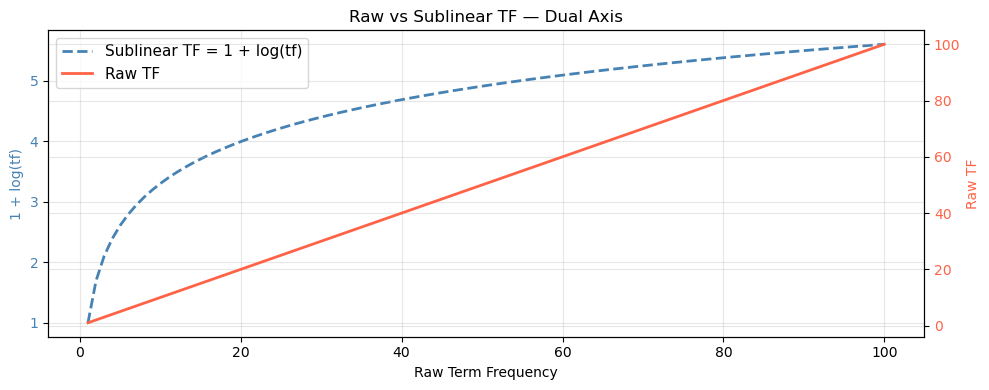

In [105]:
tf_vals = np.arange(1, 101)
raw_tf = tf_vals.astype(float)
sublinear_tf = 1 + np.log(tf_vals)
 
fig, ax1 = plt.subplots(figsize=(10, 4))
 
color_sub = "steelblue"
color_raw = "tomato"
 
ax1.plot(tf_vals, sublinear_tf, label="Sublinear TF = 1 + log(tf)", lw=2, color=color_sub, linestyle="--")
ax1.set_xlabel("Raw Term Frequency")
ax1.set_ylabel("1 + log(tf)", color=color_sub)
ax1.tick_params(axis="y", labelcolor=color_sub)
 
ax2 = ax1.twinx()
ax2.plot(tf_vals, raw_tf, label="Raw TF", lw=2, color=color_raw)
ax2.set_ylabel("Raw TF", color=color_raw)
ax2.tick_params(axis="y", labelcolor=color_raw)
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)
 
ax1.set_title("Raw vs Sublinear TF — Dual Axis")
plt.tight_layout()
plt.show()
 

In [106]:
2+2

4

## 1.6 L2 Normalization and Cosine Similarity

### The Length Problem

Even with sublinear TF, longer documents will tend to have larger vector magnitudes simply because they contain more words. We need to normalize vectors so that **direction** (what the document is about) matters, not **magnitude** (how long it is).

**L2 Normalization** scales each document vector to unit length:

$$\hat{v} = \frac{v}{\|v\|_2} = \frac{v}{\sqrt{\sum_i v_i^2}}$$

After this, every vector lies on the unit hypersphere ($\|\hat{v}\| = 1$).



### Cosine Similarity

With unit vectors, **cosine similarity** reduces to a simple **dot product**:

$$\text{cos\_sim}(q, d) = \frac{q \cdot d}{\|q\| \cdot \|d\|} = q \cdot d \quad \text{(when both are L2-normalized)}$$

Properties:
- **1.0** = identical direction (maximum similarity)
- **0.0** = orthogonal (no shared terms at all)
- Negative values cannot occur with TF-IDF (all components ≥ 0)

**Why cosine over Euclidean distance?** Euclidean distance is dominated by vector magnitude — a long document far from a short one simply because it has more words. Cosine similarity ignores magnitude and focuses purely on the **angle** (i.e., the *proportion* of terms), which is what we care about.

In [107]:
# 1. Convert the TF-IDF DataFrame into a raw numeric array (matrix)
# 2. Initialize an empty list to store the normalized vectors
# 3. Loop through each document's vector (row) in the matrix
# 4. Calculate the sum of squares for all values in the current row
# 5. Calculate the square root of that sum to get the L2 Norm (length of the vector)
# 6. Check if the norm is zero (to prevent division by zero errors)
# 7. If the norm is zero, keep the row as all zeros
# 8. Otherwise, create a new list for the normalized row
# 9. Loop through each individual TF-IDF score in the row
# 10. Divide each score by the row's L2 Norm to normalize it
# 11. Append the normalized row to our final matrix
# 12. Convert the final matrix back into a clean Pandas DataFrame

tfidf_arr = tfidf_df.values.astype(float)
tfidf_normed_list = []

for row in tfidf_arr:
    # Calculate sum of squares: x^2 + y^2 + z^2 ...
    sum_of_squares = 0
    for value in row:
        sum_of_squares += value ** 2
    
    # Calculate the L2 Norm (Length)
    l2_norm = np.sqrt(sum_of_squares)
    
    # Handle the division and normalization
    normed_row = []
    if l2_norm == 0:
        normed_row = [0.0] * len(row)
    else:
        for value in row:
            normed_row.append(value / l2_norm)
            
    tfidf_normed_list.append(normed_row)

# Re-wrap it into a DataFrame for a nice display
tfidf_normed = pd.DataFrame(
    tfidf_normed_list, 
    columns=vocab, 
    index=tfidf_df.index
)

tfidf_normed = tfidf_normed.round(4)
tfidf_normed

,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,0.3890,0.0000,0.0000,0.0000,0.7780,0.0000,0.0000,0.4934,0.0000
Doc 1,0.0000,0.0000,0.6176,0.0000,0.0000,0.4869,0.0000,0.6176,0.0000,0.0000
Doc 2,0.5774,0.0000,0.0000,0.5774,0.0000,0.0000,0.5774,0.0000,0.0000,0.0000
Doc 3,0.0000,0.7444,0.0000,0.0000,0.4721,0.0000,0.0000,0.0000,0.0000,0.4721


In [108]:
# L2-normalize the TF-IDF matrix
# tfidf_arr = tfidf_df.values.astype(float)
# l2 = np.sqrt(np.sum(tfidf_arr ** 2, axis=1, keepdims=True))
# l2[l2 == 0] = 1.0
# tfidf_normed = tfidf_arr / l2

In [109]:


# Build and normalize a query vector for "سنگ کلیه"
query = "سنگ کلیه"
q_c = Counter(query.split())
q_vec = np.array([q_c.get(t, 0) * idf_values[t] for t in vocab])
q_vec = q_vec / (np.linalg.norm(q_vec) or 1.0)
q_vec = q_vec.round(4)
# Compute cosine similarity (= dot product since both are normalized)
print(f"Query: '{query}'\n")
print(f"Query ٰVector : '{q_vec}'\n")

Query: 'سنگ کلیه'

Query ٰVector : '[0.     0.     0.     0.     0.     0.6191 0.     0.     0.7853 0.    ]'



In [110]:
tfidf_normed.iloc[0].tolist()

[0.0, 0.389, 0.0, 0.0, 0.0, 0.778, 0.0, 0.0, 0.4934, 0.0]

In [111]:



similarities = []
for i in range(len(corpus)):
    sim = np.dot(q_vec, tfidf_normed.iloc[i])
    similarities.append(sim)
    tag = "✅ Relevant" if sim > 0.3 else ("⚠️ Partial" if sim > 0.1 else "❌ Irrelevant")
    print(f"  Doc {i}: {corpus[i]:<25} sim={sim:.4f}  {tag}")

ranked = sorted(enumerate(similarities), key=lambda x: -x[1])
print(f"\n→ Ranking: {' > '.join(f'Doc {i} ({s:.3f})' for i, s in ranked)}")

  Doc 0: سنگ کلیه درد سنگ          sim=0.8691  ✅ Relevant
  Doc 1: سنگ مثانه درمان           sim=0.3014  ✅ Relevant
  Doc 2: دکتر خوب عالی             sim=0.0000  ❌ Irrelevant
  Doc 3: درد کمر دیسک درد          sim=0.0000  ❌ Irrelevant

→ Ranking: Doc 0 (0.869) > Doc 1 (0.301) > Doc 2 (0.000) > Doc 3 (0.000)


## Vectorizer Configuration — Why Each Parameter?

| Parameter | Value | Why? |
|---|---|---|
| `tokenizer=str.split` | split on space | Text is already tokenized by preprocessing |
| `preprocessor=None` | none | Do not lowercase/strip — preprocessing already did it |
| `token_pattern=None` | disable | Required when passing a custom tokenizer |
| `min_df=2` | 2 | Ignore terms in only 1 doctor → typos, very rare names |
| `max_df=0.95` | 95% | Ignore terms in >95% of doctors → too common to be useful |
| `ngram_range=(1, 2)` | unigram + bigram | Capture phrases like `سنگ کلیه` as single features |
| `max_features=60000` | 60K | Keep memory bounded; covers vast majority of useful terms |
| `sublinear_tf=True` | True | `1 + log(tf)` — compress huge counts (Part 1.7) |
| `norm='l2'` | L2 | Fair comparison regardless of doc length (Part 1.4) |

## 1.7 Verification: Our Math = sklearn

Let's confirm that sklearn's `TfidfVectorizer` produces the **exact same results** as our manual computation. This builds confidence that we understand the algorithm correctly before applying it to real data.

In [112]:


vec_demo = TfidfVectorizer(
    tokenizer=str.split,    # text is already tokenized
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    sublinear_tf=True,      # 1 + log(tf)
    norm='l2',              # L2 normalize each row
)

X_demo = vec_demo.fit_transform(corpus)
sims_sk = cosine_similarity(vec_demo.transform([query]), X_demo).ravel()

print(f"Query: '{query}'\n")
for i, (m, s) in enumerate(zip(similarities, sims_sk)):
    print(f"  Doc {i}: manual={m:.4f}  sklearn={s:.4f}  {'✓ Match' if abs(m-s)<0.01 else '✗ Mismatch'}")

Query: 'سنگ کلیه'

  Doc 0: manual=0.8691  sklearn=0.8736  ✓ Match
  Doc 1: manual=0.3014  sklearn=0.3015  ✓ Match
  Doc 2: manual=0.0000  sklearn=0.0000  ✓ Match
  Doc 3: manual=0.0000  sklearn=0.0000  ✓ Match


## 1.8 N-grams: Capturing Multi-Word Medical Phrases

With unigrams only, the query "سنگ کلیه" (kidney stone) is decomposed into two independent terms: "سنگ" and "کلیه". This means a document about "سنگ صفرا" (gallstone) would score similarly to one about "سنگ کلیه", because both contain "سنگ".

By adding **bigrams** (`ngram_range=(1,2)`), we create features like:
- Unigrams: `سنگ`, `کلیه`, `صفرا`, ...
- Bigrams: `سنگ کلیه`, `سنگ صفرا`, ...

Now "سنگ کلیه" is a **single feature** with its own IDF weight, and a document about gallstones won't match it.

This is particularly important in medical text where **multi-word terms** carry specific meanings: "سنگ کلیه" ≠ "سنگ مثانه" ≠ "سنگ صفرا".

In [113]:
c_bi = ["سنگ کلیه درد شدید", "سنگ صفرا درمان", "کلیه پیوند عمل"]
v1 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,1), norm="l2", sublinear_tf=True)
v2 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,2), norm="l2", sublinear_tf=True)


In [114]:

s1 = cosine_similarity(v1.fit_transform(c_bi), v1.transform(["سنگ کلیه"])).ravel()
s2 = cosine_similarity(v2.fit_transform(c_bi), v2.transform(["سنگ کلیه"])).ravel()

print(f"Query: 'سنگ کلیه'\n")
for i, d in enumerate(c_bi):
    delta = "↑" if s2[i] > s1[i] + 0.01 else ("↓" if s2[i] < s1[i] - 0.01 else "=")
    print(f"  {d:<25}  Unigram={s1[i]:.4f}  Bigram={s2[i]:.4f}  {delta}")
print(f"\n→ Bigram features created: {sorted(v2.get_feature_names_out())}")

Query: 'سنگ کلیه'

  سنگ کلیه درد شدید          Unigram=0.6053  Bigram=0.5919  ↓
  سنگ صفرا درمان             Unigram=0.3349  Bigram=0.1841  ↓
  کلیه پیوند عمل             Unigram=0.3349  Bigram=0.1841  ↓

→ Bigram features created: ['درد', 'درد شدید', 'درمان', 'سنگ', 'سنگ صفرا', 'سنگ کلیه', 'شدید', 'صفرا', 'صفرا درمان', 'عمل', 'پیوند', 'پیوند عمل', 'کلیه', 'کلیه درد', 'کلیه پیوند']


---
# Part 2: Medical Stopwords Pipeline
---

## Why Domain-Specific Stopwords?

Our Preprocessing notebook already removed **standard Persian stopwords** (از، به، که، در، ...). But in a medical review corpus, a new class of "noise words" emerges:

- **"عالی"** (excellent) appears in 15,000+ reviews — it tells us nothing about *what* the doctor treats.
- **"دکتر"** (doctor) appears in virtually every review.
- **"مطب"** (office), **"نوبت"** (appointment) — service terms, not diagnostic.

If we leave these in, our TF-IDF index will be dominated by sentiment and service vocabulary. A query for "سنگ کلیه" might retrieve doctors who have many reviews saying "عالی" rather than doctors whose patients actually discuss kidney stones.

### The Three-Layer Architecture

We can't just blindly remove high-frequency words — some of them are medically critical ("درد" appears everywhere but is essential for pain-related queries). Our system has three layers:

```
Layer 1: SEED (Manual)         ~60 words curated by domain knowledge
Layer 2: AUTO-DISCOVERY        Data-driven: doc_ratio > 0.6 AND entropy > 0.6
Layer 3: SAFETY GUARDS         HIGH_RISK_KEEP + ALLOWLIST_LATIN → never removed
```

## 2.1 Layer 1: Manual Seed Stopwords

These words were identified through manual analysis of the corpus (in our EDA notebook) and grouped into semantic categories:

| Category | Examples | Why remove? |
|----------|---------|-------------|
| **Praise** | عالی, خوب, بهترین, محشر | Appear in ~80% of positive reviews — zero diagnostic signal |
| **Thanks** | مرسی, ممنون, تشکر, سپاس | Courtesy language, uniform across specialties |
| **Doctor addressing** | دکتر, پزشک, خانم, آقا | Present in virtually every review |
| **Clinic operations** | مطب, منشی, نوبت, هزینه, ویزیت | Service-related, not diagnostic |
| **Behavioral adjectives** | حوصله, اخلاق, مهربان, دلسوز | Behavioral — shared across all specialties |
| **Fillers** | سلام, واقعا, مراجعه | No semantic content for retrieval |

In [115]:
MEDICAL_STOPWORDS_SEED = {
    # praise
    "عالی", "خوب", "بهترین", "فوقالعاده", "محشر", "بینظیر", "راضی", "رضایت", "ناراضی",
    # thanks
    "مرسی", "ممنون", "تشکر", "سپاس", "قدردانی",
    # doctor address
    "دکتر", "پزشک", "خانم", "آقا", "آقای", "جناب", "ایشون", "ایشان",
    # clinic operations
    "مطب", "منشی", "پرسنل", "پذیرش", "نوبت", "نوبتدهی", "وقت", "معطلی",
    "شلوغ", "شلوغی", "هزینه", "ویزیت", "پرداخت", "کارت", "بیمه",
    "تومان", "تومن", "خدمات", "برخورد", "پاسخگو",
    # behavioral adjectives
    "حوصله", "اخلاق", "حاذق", "مودب", "محترم", "مهربان", "دلسوز", "صبور", "دقیق", "خوشبرخورد",
    # fillers
    "سلام", "درود", "واقعا", "فعلا", "مراجعه", "نتیجه", "هستم", "هستن", "هستند", "داشتم", "بودم", "بودن",
}
print(f"Seed stopwords: {len(MEDICAL_STOPWORDS_SEED)} words")

Seed stopwords: 64 words


## 2.2 Bigram Stopwords: Phrase-Level Removal

Some praise phrases consist of two words where **each word individually has legitimate medical uses**:

| Bigram to Remove | As Praise | Individual Medical Uses |
|-----------------|-----------|------------------------|
| "فوق" + "العاده" | "فوق‌العاده" = extraordinary | "فوق تخصص" = super-specialist |
| "بی" + "نظیر" | "بی‌نظیر" = unparalleled | "بی‌اختیاری" = incontinence, "بی‌حسی" = anesthesia |

The solution: only remove these words **when they appear together** as a pair.

In [116]:
MEDICAL_STOPWORD_BIGRAMS = {("فوق", "العاده"), ("بی", "نظیر")}
print(f"Bigram stopwords: {len(MEDICAL_STOPWORD_BIGRAMS)} pairs")

Bigram stopwords: 2 pairs


## 2.3 Layer 3: Safety Guards — Never Remove These

Some words appear in many documents (high df) but are **medically critical**. Our auto-discovery algorithm might flag them as stopword candidates, so we need explicit protection.

**HIGH_RISK_KEEP** — clinically essential terms:
- **درد** (pain) — the core of most patient queries
- **درمان** (treatment), **تشخیص** (diagnosis), **دارو** (medication)
- **عمل** (surgery), **جراحی** (surgical)
- **بی** — component of بی‌اختیاری (incontinence), بی‌حسی (anesthesia)
- **فوق** — component of فوق‌تخصص (super-specialist)

**ALLOWLIST_LATIN** — Latin medical acronyms that must always survive:
- Imaging: `mri`, `ct`
- Ligaments: `acl`, `mcl`, `pcl`
- Fertility: `ivf`, `iui`
- Urology: `pcnl`, `rirs`, `tul`
- Vertebrae: `l5`, `s1`, `t12`

In [117]:
HIGH_RISK_KEEP = {"درد", "دارو", "درمان", "تشخیص", "عمل", "جراحی", "بی", "فوق"}
MEDICAL_ALLOWLIST_LATIN = {
    "acl", "mcl", "pcl", "mri", "ct", "prp", "hpv", "psa",
    "ivf", "iui", "pcnl", "rirs", "tul", "l5", "s1", "t12", "ms", "avm", "co2",
}

# Build effective set = seed MINUS safety guards
def norm_tok(t):
    return str(t).strip().lower().replace("\u200c", "")

effective_medical_sw = {norm_tok(x) for x in MEDICAL_STOPWORDS_SEED if norm_tok(x)}
effective_medical_sw -= HIGH_RISK_KEEP | MEDICAL_ALLOWLIST_LATIN | {t for t in effective_medical_sw if len(t) < 2}
print(f"Seed: {len(MEDICAL_STOPWORDS_SEED)} → Effective (after safety filter): {len(effective_medical_sw)}")

Seed: 64 → Effective (after safety filter): 64


## 2.5 Creating Two Text Variants (Baseline vs Medical)

At this point our comments are already tokenized (space-separated tokens).
We now create two retriever inputs:

- **text_baseline**: standard Persian stopwords already removed in NB2.
- **text_medical**: baseline text with **domain-specific medical stopwords** removed on top.

Why do we need this?
Medical review corpora contain a lot of repeated non-clinical language (praise, thanks, clinic operations).
If we do not remove them, TF‑IDF will waste its capacity on non-medical vocabulary.

In [118]:
# ------------------------------------------------------------
# Build text_medical by applying medical stopwords on top of baseline
# ------------------------------------------------------------

def norm_tok(t: str) -> str:
    """Normalize tokens for comparison (lower + remove ZWNJ)."""
    return str(t).strip().lower().replace("\u200c", "")

# Normalize stopword sets once
effective_medical_sw_norm = {norm_tok(x) for x in effective_medical_sw if norm_tok(x)}

# Normalize bigram stopwords once
MEDICAL_STOPWORD_BIGRAMS_NORM = {(norm_tok(a), norm_tok(b)) for (a, b) in MEDICAL_STOPWORD_BIGRAMS}

def apply_medical_stopwords_to_tokenized_text(s: str) -> str:
    """
    Input: already-tokenized text (space-separated).
    Output: tokenized text with medical stopwords removed (uni + selected bigrams).
    """
    toks = [norm_tok(x) for x in str(s).split() if norm_tok(x)]
    out = []
    i = 0
    while i < len(toks):
        # Bigram stopwords (remove only if the pair occurs together)
        if i + 1 < len(toks) and (toks[i], toks[i + 1]) in MEDICAL_STOPWORD_BIGRAMS_NORM:
            i += 2
            continue
        # Unigram stopwords
        if toks[i] in effective_medical_sw_norm:
            i += 1
            continue
        out.append(toks[i])
        i += 1
    return " ".join(out)

comments_df["text_medical"] = comments_df["text_baseline"].apply(apply_medical_stopwords_to_tokenized_text)

n_empty = (comments_df["text_medical"].str.strip() == "").sum()
print(f"Medical texts empty after filter: {n_empty:,} ({n_empty/len(comments_df)*100:.2f}%)")

# Quick before/after examples
sample = comments_df.sample(5, random_state=42)[["text_baseline", "text_medical"]]
sample

Medical texts empty after filter: 7,208 (11.31%)


,text_baseline,text_medical
57050,عالی بود,بود
943,العاده,العاده
31375,سنگ کلیه داشتم ویک مشکل پروستات مراجعه,سنگ کلیه ویک مشکل پروستات
60105,بودنند,بودنند
43168,بیمار دکتر بودم,بیمار


## Part 3: Building the Doctor-Level Corpus

Our retrieval target is **a doctor**, not an individual comment.
So we concatenate all comments per doctor into one "doctor document".

Important product decision:

- **Baseline index** (service/behavior queries): uses *all comments*.
- **Medical recommendation index** (clinical queries): uses **only high-satisfaction comments** (e.g., rate ≥ 4).

Why?
If a doctor is mentioned with a disease term mostly in negative reviews, we do NOT want them to be recommended for that condition.

In [119]:
def build_doctor_documents(df, text_col, min_rate=None):
    """Concatenate comments per doctor into one document.
    If min_rate is set, only use comments with rate >= min_rate.
    """
    valid = df[df[text_col].str.strip() != ""].copy()

    # NEW: positive-only filter (for recommendation use-case)
    if (min_rate is not None) and ("rate" in valid.columns):
        valid["rate_num"] = pd.to_numeric(valid["rate"], errors="coerce")
        valid = valid[valid["rate_num"].ge(min_rate)].copy()

    docs = (valid.groupby("doctor_id")[text_col]
                 .apply(lambda x: " ".join(x))
                 .reset_index()
                 .rename(columns={text_col: "document"}))

    docs["n_comments"] = valid.groupby("doctor_id").size().values
    docs["n_tokens"] = docs["document"].str.split().str.len()
    return docs

In [120]:
# ------------------------------------------------------------
# Build doctor-level corpora (baseline vs medical recommendation)
# ------------------------------------------------------------

dd_baseline = build_doctor_documents(comments_df, "text_baseline", min_rate=None)
dd_medical  = build_doctor_documents(comments_df, "text_medical",  min_rate=4.0)

print("Doctor corpus sizes:")
print(f"  baseline: {len(dd_baseline):,} doctors")
print(f"  medical : {len(dd_medical):,} doctors (using only rate >= 4.0 comments)")

# Coverage check (are we losing many doctors?)
missing_in_medical = set(dd_baseline["doctor_id"]) - set(dd_medical["doctor_id"])
print(f"Doctors present in baseline but missing in medical: {len(missing_in_medical)}")
dd_medical.head(3)

Doctor corpus sizes:
  baseline: 545 doctors
  medical : 543 doctors (using only rate >= 4.0 comments)
Doctors present in baseline but missing in medical: 2


,doctor_id,document,n_comments,n_tokens
0,100246,زگیل ناخن درمانم تشخیص درست خارش بدن ودرمان دق...,86,297
1,100332,بسیار درد شانه زانو دقت تنگی کانال دست مشکل در...,104,469
2,102091,یکدفعه شدم جوش پوست آزمایش نوشته جوابشون ببرم ...,181,744


---
# Part 4: Building the TF-IDF Index
---

Now we apply everything from Part 1 to our **real** doctor corpus. We build two separate indexes with identical hyperparameters:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `tokenizer=str.split` | — | Text is pre-tokenized; no further splitting needed |
| `min_df=2` | ≥ 2 doctors | Terms in only 1 doctor are likely typos or patient names |
| `max_df=0.95` | ≤ 95% | Terms in >95% of doctors are too ubiquitous to discriminate |
| `ngram_range=(1,2)` | uni + bigram | Captures multi-word medical terms ("سنگ کلیه", "دیسک کمر") |
| `max_features=60000` | 60K | Balances vocabulary coverage against memory |
| `sublinear_tf=True` | `1+log(tf)` | Prevents high-volume doctors from dominating |
| `norm="l2"` | unit vectors | Enables fair cosine similarity comparison |

In [121]:
# ------------------------------------------------------------
# Part 4 — Build TF‑IDF indexes (baseline + medical)
# ------------------------------------------------------------

idx_baseline = build_tfidf_index(dd_baseline, "baseline")
idx_medical  = build_tfidf_index(dd_medical,  "medical")

  [baseline] 545 doctors × 35,064 features | sparsity: 98.4645% | nnz: 293,425
  [medical] 543 doctors × 25,924 features | sparsity: 98.6396% | nnz: 191,496


In [122]:
# Verify: top keywords should reflect each doctor's specialty
def top_kw(idx, doc_i, n=10):
    row = idx["X"][doc_i].toarray().ravel()
    feat = idx["vectorizer"].get_feature_names_out()
    top = row.argsort()[-n:][::-1]
    return [(feat[j], round(row[j], 3)) for j in top if row[j] > 0]

for i in range(min(3, len(idx_medical["doctor_ids"]))):
    did = idx_medical["doctor_ids"][i]
    print(f"{name_map.get(did,'?')} [{specialty_map.get(did,'?')}]")
    print(f"  Medical keywords:  {', '.join(w for w,_ in top_kw(idx_medical, i, 8))}\n")

دکتر علیرضا تقی زاده [متخصص پوست ، مو و زیبایی]
  Medical keywords:  خارش بدن, پوست, جوش, رفع تشخیص, جوش صورت, پوسته, خارش, سرعت

دکتر کورش فاتح [متخصص ارتوپدی - تعویض مفصل]
  Medical keywords:  فاتح, وارتروز, زانو, پارگی مینیسک, ارتروسکوپی شانه, مینیسک زانو, درد شانه, ارتروسکوپی

دکتر منصور اصفهانی [متخصص پوست ، مو و لیزر]
  Medical keywords:  اصفهانی, آکنه جوش, ریزش, ریزش سکهای, سکهای, جوش, سکهای درمان, ریزش مو



In [123]:
# ------------------------------------------------------------
# Save both indexes (so later notebooks / scripts can reuse them)
# ------------------------------------------------------------

for idx_obj, fname in [
    (idx_baseline, "tfidf_retriever_baseline.joblib"),
    (idx_medical,  "tfidf_retriever_medical.joblib"),
]:
    joblib.dump(idx_obj, fname, compress=3)
    print(f"Saved '{fname}' ({os.path.getsize(fname)/1024/1024:.1f} MB)")

Saved 'tfidf_retriever_baseline.joblib' (2.2 MB)
Saved 'tfidf_retriever_medical.joblib' (1.5 MB)


### 🔬 Real Doctor TF-IDF Explorer

In Part 1 we explored TF-IDF on 4 toy sentences. Now let's explore **real doctor data**.

The CLI below lets you:
- **Pick doctors by number** → see their top TF-IDF terms with bar charts
- **Compare two doctors** → side-by-side heatmap of shared terms
- **Search any term** → which doctors have the highest weight for it?
- **Switch variant** → see how Baseline vs Medical changes the picture

In [124]:
# ============================================================
#  Doctor TF-IDF Explorer — Pure CLI
#  Zero external dependencies beyond your project's own libs
# ============================================================

import os
import sys
import random
import unicodedata

# ─────────────────────────────────────────────────────────────
#  ① ANSI Color Palette
# ─────────────────────────────────────────────────────────────
class C:
    RESET  = '\033[0m'
    BOLD   = '\033[1m'
    DIM    = '\033[2m'
    WHITE  = '\033[97m'
    CYAN   = '\033[96m'
    YELLOW = '\033[93m'
    RED    = '\033[91m'
    GRAY   = '\033[90m'
    BLUE   = '\033[38;5;39m'
    LBLUE  = '\033[38;5;51m'
    DBLUE  = '\033[38;5;27m'
    ORANGE = '\033[38;5;208m'
    GREEN  = '\033[38;5;83m'

def cl(text, *codes) -> str:
    return ''.join(codes) + str(text) + C.RESET


# ─────────────────────────────────────────────────────────────
#  ② Persian/Arabic helpers — فقط built-in unicodedata
# ─────────────────────────────────────────────────────────────
def _is_rtl(ch: str) -> bool:
    """آیا این کاراکتر RTL (فارسی/عربی/عبری) است؟"""
    try:
        return unicodedata.bidirectional(ch) in ('R', 'AL', 'AN', 'RLE', 'RLO')
    except Exception:
        return False

def has_persian(text: str) -> bool:
    return any(_is_rtl(c) for c in text if not c.isspace())

def char_width(ch: str) -> int:
    """
    عرض نمایشی یک کاراکتر.
    کاراکترهای CJK → 2 | بقیه → 1
    """
    eaw = unicodedata.east_asian_width(ch)
    return 2 if eaw in ('W', 'F') else 1

def str_width(text: str) -> int:
    """عرض واقعی یک رشته روی ترمینال (بدون ANSI codes)."""
    # strip ANSI escape sequences first
    import re
    clean = re.sub(r'\033\[[0-9;]*m', '', text)
    return sum(char_width(c) for c in clean)

def pad(text: str, width: int, align: str = 'left') -> str:
    """
    رشته را با در نظر گرفتن عرض واقعی کاراکترهای فارسی pad می‌کند.
    align: 'left' | 'right' | 'center'
    """
    current = str_width(text)
    spaces  = max(0, width - current)
    if align == 'right':
        return ' ' * spaces + text
    if align == 'center':
        l = spaces // 2
        return ' ' * l + text + ' ' * (spaces - l)
    return text + ' ' * spaces  # left (default)

def fa(text: str) -> str:
    """
    متن فارسی را برای ترمینال آماده می‌کند.
    ترمینال‌های مدرن (Windows Terminal / GNOME / iTerm2 / VS Code)
    Reshaping و BiDi را خودشان انجام می‌دهند.
    این تابع فقط اطمینان می‌دهد string سالم unicode است.
    """
    if not text or not isinstance(text, str):
        return str(text) if text is not None else ''
    # NFC normalization — استانداردسازی فرم یونیکد
    return unicodedata.normalize('NFC', text)


# ─────────────────────────────────────────────────────────────
#  ③ Terminal / Layout Helpers
# ─────────────────────────────────────────────────────────────
def tw() -> int:
    try:
        return os.get_terminal_size().columns
    except Exception:
        return 80

def sep(char: str = '─', width: int = None, color: str = C.GRAY) -> str:
    w = width or min(tw(), 72)
    return f"{color}{char * w}{C.RESET}"

def box_header(title: str, subtitle: str = '') -> str:
    w   = min(tw(), 72)
    out = [
        f"\n{C.BOLD}{C.BLUE}{'═' * w}{C.RESET}",
        f"{C.BOLD}{C.WHITE}  {fa(title)}{C.RESET}",
    ]
    if subtitle:
        out.append(f"{C.GRAY}  {fa(subtitle)}{C.RESET}")
    out.append(f"{C.BLUE}{'═' * w}{C.RESET}")
    return '\n'.join(out)


# ─────────────────────────────────────────────────────────────
#  ④ Unicode Bar Builder
# ─────────────────────────────────────────────────────────────
_BLOCKS = ' ▏▎▍▌▋▊▉█'

def make_bar(value: float, max_val: float,
             width: int = 28, color: str = C.BLUE) -> str:
    """Smooth Unicode bar با sub-block characters."""
    if max_val == 0:
        return ' ' * width
    ratio   = max(0.0, min(1.0, value / max_val))
    filled  = ratio * width
    full    = int(filled)
    sub_idx = int((filled - full) * 8)
    sub     = _BLOCKS[sub_idx] if sub_idx else ''
    bar     = '█' * full + sub
    return f"{color}{bar:<{width}}{C.RESET}"

def gradient_bar(value: float, max_val: float, width: int = 28) -> str:
    r     = value / max_val if max_val else 0
    color = C.LBLUE if r > 0.75 else C.BLUE if r > 0.40 else C.DBLUE
    return make_bar(value, max_val, width, color)


# ─────────────────────────────────────────────────────────────
#  ⑤ Show Doctor Profile
# ─────────────────────────────────────────────────────────────
def show_doctor_profile(idx_obj, doc_idx, dd_df, n_terms: int = 12):
    did   = idx_obj['doctor_ids'][doc_idx]
    nm    = fa(name_map.get(did, f'Doctor {did}'))
    sp    = fa(specialty_map.get(did, '—'))
    row   = idx_obj['X'][doc_idx].toarray().ravel()
    feat  = idx_obj['vectorizer'].get_feature_names_out()
    top_i = row.argsort()[-n_terms:][::-1]
    terms = [(fa(feat[j]), round(float(row[j]), 4))
             for j in top_i if row[j] > 0]

    nc_arr = dd_df[dd_df['doctor_id'] == did]['n_comments'].values
    nc     = int(nc_arr[0]) if len(nc_arr) > 0 else '?'

    if not terms:
        print(cl('  No terms found for this doctor.', C.RED))
        return []

    max_w  = terms[0][1]
    BAR_W  = 30
    TERM_W = 22

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('👨‍⚕️  ' + nm, C.BOLD, C.WHITE)}")
    print(f"  {cl('├─', C.GRAY)} Specialty : {cl(sp, C.CYAN)}")
    print(f"  {cl('├─', C.GRAY)} Doctor ID : {cl(str(did), C.GRAY)}")
    print(f"  {cl('└─', C.GRAY)} Comments  : {cl(str(nc), C.YELLOW)}")
    print(sep())
    print(f"  {cl('Top TF-IDF Terms', C.BOLD, C.WHITE)}  "
          f"{cl(f'({len(terms)} shown)', C.GRAY)}")
    print(sep('·', color=C.GRAY))

    # header
    h_score = pad('Score', 6)
    h_term  = pad('Term', TERM_W)
    h_bar   = pad('Bar', BAR_W)
    h_rank  = 'Rank'
    print(f"  {cl(h_score, C.GRAY)}  "
          f"{cl(h_term,  C.GRAY)}  "
          f"{cl(h_bar,   C.GRAY)}  "
          f"{cl(h_rank,  C.GRAY)}")
    print(sep('·', color=C.GRAY))

    for rank, (t, w) in enumerate(terms, 1):
        score_col = (C.LBLUE if w / max_w > 0.70 else
                     C.BLUE  if w / max_w > 0.35 else C.GRAY)
        row_dim   = C.DIM if rank % 2 == 0 else ''
        term_str  = pad(t, TERM_W)
        bar       = gradient_bar(w, max_w, BAR_W)

        print(f"  {score_col}{w:.4f}{C.RESET}  "
              f"{row_dim}{term_str}{C.RESET}  "
              f"{bar}  "
              f"{cl(f'#{rank}', C.GRAY)}")

    print(sep('═', color=C.BLUE))
    return terms


# ─────────────────────────────────────────────────────────────
#  ⑥ Compare Two Doctors (back-to-back bars)
# ─────────────────────────────────────────────────────────────
def compare_two_doctors(idx_obj, idx_a, idx_b, dd_df, n_terms: int = 10):
    ids   = idx_obj['doctor_ids']
    feat  = idx_obj['vectorizer'].get_feature_names_out()
    X     = idx_obj['X']

    row_a = X[idx_a].toarray().ravel()
    row_b = X[idx_b].toarray().ravel()

    top_a   = set(row_a.argsort()[-n_terms:][::-1])
    top_b   = set(row_b.argsort()[-n_terms:][::-1])
    all_top = sorted(top_a | top_b,
                     key=lambda j: max(row_a[j], row_b[j]),
                     reverse=True)

    nm_a = fa(name_map.get(ids[idx_a], ids[idx_a]))
    nm_b = fa(name_map.get(ids[idx_b], ids[idx_b]))
    sp_a = fa(specialty_map.get(ids[idx_a], '—'))
    sp_b = fa(specialty_map.get(ids[idx_b], '—'))

    max_val = max(
        [row_a[j] for j in all_top] + [row_b[j] for j in all_top],
        default=1.0
    )

    BAR_W  = 18
    TERM_W = 18

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('📊 Doctor Comparison', C.BOLD, C.WHITE)}")
    print(sep())
    print(f"  {cl('A ►', C.BOLD, C.BLUE)}  "
          f"{cl(nm_a, C.BLUE)}  {cl('[' + sp_a + ']', C.GRAY)}")
    print(f"  {cl('B ►', C.BOLD, C.ORANGE)}  "
          f"{cl(nm_b, C.ORANGE)}  {cl('[' + sp_b + ']', C.GRAY)}")
    print(sep())

    hdr = (f"  {'ScoreA':>8}  "
           f"{'◀ Dr.A':>{BAR_W}}  "
           f"{'Term':^{TERM_W}}  "
           f"{'Dr.B ▶':<{BAR_W}}  "
           f"{'ScoreB':<8}")
    print(cl(hdr, C.GRAY))
    print(sep('·', color=C.GRAY))

    for j in all_top:
        wa   = float(row_a[j])
        wb   = float(row_b[j])
        term = pad(fa(feat[j]), TERM_W, 'center')

        a_fill = int((wa / max_val) * BAR_W)
        b_fill = int((wb / max_val) * BAR_W)
        a_bar  = f"{C.BLUE}{' ' * (BAR_W - a_fill)}{'█' * a_fill}{C.RESET}"
        b_bar  = f"{C.ORANGE}{'█' * b_fill}{' ' * (BAR_W - b_fill)}{C.RESET}"

        diff   = wa - wb
        marker = (cl('◀', C.BLUE)   if diff >  0.001 else
                  cl('▶', C.ORANGE) if diff < -0.001 else
                  cl('═', C.GRAY))

        print(f"  {C.BLUE}{wa:.4f}{C.RESET}  "
              f"{a_bar}  "
              f"{cl(term, C.WHITE)}  "
              f"{b_bar}  "
              f"{C.ORANGE}{wb:.4f}{C.RESET} {marker}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑦ Search Term
# ─────────────────────────────────────────────────────────────
def search_term_in_index(idx_obj, term: str, top_n: int = 10):
    vec = idx_obj['vectorizer']
    X   = idx_obj['X']
    ids = idx_obj['doctor_ids']

    t = term.lower().strip()

    if t not in vec.vocabulary_:
        feat    = list(vec.get_feature_names_out())
        matches = [f for f in feat if t in f][:8]
        print()
        if matches:
            print(f"  {cl('⚠️  Not exact. Did you mean:', C.YELLOW)}")
            for i, m in enumerate(matches, 1):
                print(f"    {cl(str(i) + '.', C.GRAY)}  {cl(fa(m), C.CYAN)}")
        else:
            print(f"  {cl('❌  Term not found in vocabulary.', C.RED)}")
        return

    ti       = vec.vocabulary_[t]
    idf      = float(vec.idf_[ti])
    col      = X[:, ti].toarray().ravel()
    top_docs = col.argsort()[-top_n:][::-1]

    results = []
    for di in top_docs:
        w = float(col[di])
        if w == 0:
            break
        did = ids[di]
        results.append((fa(name_map.get(did, did)),
                        fa(specialty_map.get(did, '—')),
                        w))

    if not results:
        print(f"\n  {cl('No results found.', C.GRAY)}")
        return

    max_w  = results[0][2]
    BAR_W  = 30
    NAME_W = 22

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl('🔎 Search Results', C.BOLD, C.WHITE)}")
    print(f"  {cl('Term :', C.GRAY)} {cl(fa(term), C.CYAN, C.BOLD)}")
    print(f"  {cl('IDF  :', C.GRAY)} {cl(f'{idf:.4f}', C.YELLOW)}")
    print(f"  {cl('Docs :', C.GRAY)} {cl(str(len(results)), C.GRAY)}")
    print(sep('·', color=C.GRAY))

    h_rank = pad('Rank', 4)
    h_scr  = pad('Score', 6)
    h_bar  = pad('Bar', BAR_W)
    h_nm   = pad('Doctor', NAME_W)
    print(f"  {cl(h_rank, C.GRAY)}  "
          f"{cl(h_scr,  C.GRAY)}  "
          f"{cl(h_bar,  C.GRAY)}  "
          f"{cl(h_nm,   C.GRAY)}")
    print(sep('·', color=C.GRAY))

    for i, (nm, sp, w) in enumerate(results, 1):
        r         = w / max_w
        score_col = C.LBLUE if r > 0.75 else C.BLUE if r > 0.4 else C.GRAY
        bar       = make_bar(w, max_w, BAR_W, score_col)
        nm_str    = pad(nm, NAME_W)

        print(f"  {cl(f'#{i:>2}', C.GRAY)}  "
              f"{score_col}{w:.4f}{C.RESET}  "
              f"{bar}  "
              f"{cl(nm_str, C.WHITE)}  "
              f"{cl('(' + sp[:14] + ')', C.GRAY)}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑧ Top-N Doctors by TF-IDF Mass
# ─────────────────────────────────────────────────────────────
def show_top_n(idx_obj, count: int = 10):
    ids    = idx_obj['doctor_ids']
    X      = idx_obj['X']
    count  = min(count, len(ids))
    masses = X.sum(axis=1).A1
    top_i  = masses.argsort()[-count:][::-1]
    max_m  = float(masses[top_i[0]])
    BAR_W  = 28

    print()
    print(sep('═', color=C.BLUE))
    print(f"  {cl(f'🏆 Top {count} Doctors by TF-IDF Mass', C.BOLD, C.WHITE)}")
    print(sep('·', color=C.GRAY))

    for rank, di in enumerate(top_i, 1):
        did  = ids[di]
        nm   = fa(name_map.get(did, did))
        sp   = fa(specialty_map.get(did, '—'))
        mass = float(masses[di])
        bar  = gradient_bar(mass, max_m, BAR_W)

        print(f"  {cl(f'#{rank:>3}', C.GRAY)}  "
              f"{bar}  "
              f"{cl(f'{mass:8.2f}', C.YELLOW)}  "
              f"{cl(pad(nm, 22), C.WHITE)}  "
              f"{cl('(' + sp[:14] + ')', C.GRAY)}")

    print(sep('═', color=C.BLUE))


# ─────────────────────────────────────────────────────────────
#  ⑨ List Doctors
# ─────────────────────────────────────────────────────────────
def list_doctors(idx_obj, start: int = 0, page: int = 20):
    ids   = idx_obj['doctor_ids']
    n     = len(ids)
    start = max(0, min(start, n - 1))
    end   = min(start + page, n)

    print()
    print(sep('─', color=C.GRAY))
    print(f"  {cl(f'Doctors [{start} – {end-1}] of {n}', C.BOLD, C.WHITE)}")
    print(sep('·', color=C.GRAY))

    for i in range(start, end):
        did = ids[i]
        nm  = fa(name_map.get(did, did))
        sp  = fa(specialty_map.get(did, '—'))
        print(f"    {cl(f'[{i:>4}]', C.GRAY)}  "
              f"{cl(pad(nm, 28), C.WHITE)}  "
              f"{cl('(' + sp[:20] + ')', C.GRAY)}")

    print(sep('─', color=C.GRAY))
    if end < n:
        print(f"  {cl(f'→ type: list {end}  for next page', C.DIM)}")


# ─────────────────────────────────────────────────────────────
#  ⑩ Help
# ─────────────────────────────────────────────────────────────
HELP_ROWS = [
    ('<number>',         'نمایش پروفایل پزشک با این شماره'),
    ('compare <a> <b>',  'مقایسه دو پزشک'),
    ('search  <term>',   'جستجوی یک واژه در همه پزشک‌ها'),
    ('top     [n]',      'بهترین n پزشک بر اساس TF-IDF (پیش‌فرض ۱۰)'),
    ('list    [start]',  'فهرست ۲۰ پزشک از شماره start'),
    ('random',           'نمایش یک پزشک تصادفی'),
    ('help',             'نمایش این راهنما'),
    ('exit / q',         'خروج'),
]

def print_help():
    print(f"\n  {cl('دستورات:', C.BOLD, C.WHITE)}")
    for cmd_str, desc in HELP_ROWS:
        cmd_col  = cl(pad(cmd_str, 18), C.CYAN)
        desc_col = cl(fa(desc), C.GRAY)
        print(f"    {cmd_col}  {desc_col}")


# ─────────────────────────────────────────────────────────────
#  ⑪ Main CLI Loop
# ─────────────────────────────────────────────────────────────
def doctor_explorer_cli(idx_obj, dd_df, variant_label: str):
    ids = idx_obj['doctor_ids']
    n   = len(ids)

    print(box_header(
        f"🔬 Doctor TF-IDF Explorer  [{variant_label.upper()}]",
        f"{n} doctors  |  {idx_obj['X'].shape[1]:,} vocabulary features"
    ))

    print_help()
    list_doctors(idx_obj, start=0, page=10)

    while True:
        try:
            raw = input(
                f"\n🔍 {cl('[' + variant_label + ']', C.CYAN)}"
                f"{cl('> ', C.GRAY)}"
            ).strip()
        except (EOFError, KeyboardInterrupt):
            print(f"\n{cl('  خداحافظ!', C.GRAY)}\n")
            break

        if not raw:
            continue

        low   = raw.lower()
        parts = raw.split()

        # ── exit ─────────────────────────────────────────────
        if low in {'exit', 'quit', 'q', 'خروج'}:
            print(f"\n{cl('  خداحافظ!', C.GRAY)}\n")
            break

        # ── help ─────────────────────────────────────────────
        elif low in {'help', 'راهنما'}:
            print_help()

        # ── random ───────────────────────────────────────────
        elif low in {'random', 'تصادفی'}:
            show_doctor_profile(idx_obj, random.randint(0, n - 1), dd_df)

        # ── top [n] ──────────────────────────────────────────
        elif low.startswith('top'):
            count = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 10
            show_top_n(idx_obj, count)

        # ── list [start] ─────────────────────────────────────
        elif low.startswith('list'):
            start = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
            list_doctors(idx_obj, start=start, page=20)

        # ── compare <a> <b> ──────────────────────────────────
        elif low.startswith('compare'):
            if len(parts) >= 3:
                try:
                    a, b = int(parts[1]), int(parts[2])
                    if 0 <= a < n and 0 <= b < n:
                        compare_two_doctors(idx_obj, a, b, dd_df)
                    else:
                        print(cl(f'  عدد باید بین ۰ تا {n-1} باشد.', C.RED))
                except ValueError:
                    print(cl('  استفاده: compare <الف> <ب>', C.YELLOW))
            else:
                print(cl('  استفاده: compare <الف> <ب>', C.YELLOW))

        # ── search <term> ─────────────────────────────────────
        elif low.startswith('search '):
            term = raw[7:].strip()
            if term:
                search_term_in_index(idx_obj, term)
            else:
                print(cl('  استفاده: search <واژه>', C.YELLOW))

        # ── <number> → profile ───────────────────────────────
        else:
            try:
                di = int(raw)
                if 0 <= di < n:
                    show_doctor_profile(idx_obj, di, dd_df)
                else:
                    print(cl(f'  عدد باید بین ۰ تا {n-1} باشد.', C.RED))
            except ValueError:
                # implicit term search
                search_term_in_index(idx_obj, raw)


# ── اجرا ─────────────────────────────────────────────────────
doctor_explorer_cli(idx_medical, dd_medical, 'medical')


════════════════════════════════════════════════════════════════════════
  🔬 Doctor TF-IDF Explorer  [MEDICAL]
  543 doctors  |  25,924 vocabulary features
════════════════════════════════════════════════════════════════════════

  دستورات:
    <number>            نمایش پروفایل پزشک با این شماره
    compare <a> <b>     مقایسه دو پزشک
    search  <term>      جستجوی یک واژه در همه پزشک‌ها
    top     [n]         بهترین n پزشک بر اساس TF-IDF (پیش‌فرض ۱۰)
    list    [start]     فهرست ۲۰ پزشک از شماره start
    random              نمایش یک پزشک تصادفی
    help                نمایش این راهنما
    exit / q            خروج

────────────────────────────────────────────────────────────────────────
  Doctors [0 – 9] of 543
········································································
    [   0]  دکتر علیرضا تقی زاده          (متخصص پوست ، مو و زی)
    [   1]  دکتر کورش فاتح                (متخصص ارتوپدی - تعوی)
    [   2]  دکتر منصور اصفهانی            (متخصص پوست ، مو و لی)
    [   


🔍 [medical]>  exit



  خداحافظ!



### Baseline vs Medical Query Preprocessing

Golden rule:
> The query must go through the same preprocessing steps as the documents.

We produce two versions of the query:

- **baseline_query**: standard pipeline (NB2-compatible)
- **medical_query**: baseline_query + domain medical stopwords removed

This matches how we built `text_baseline` and `text_medical`.

In [125]:
from hazm import Normalizer, WordTokenizer, stopwords_list

DIGIT_MAP = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")
CTRL_RE = re.compile(r"[\u200c\u200d\u200e\u200f\u202a-\u202e\ufeff\u00ad\u2060\u180e]")
KEEP_RE = re.compile(r"[^0-9A-Za-z\u0600-\u06FF\s]")
ELONG_RE = re.compile(r"(\S)\1{2,}")
PUNCT_RE = re.compile(r"[،؛؟!٪«»]+")
DOT_RE = re.compile(r"(?<!\d)\.(?!\d)")
MULTI_SP = re.compile(r"\s+")

DEGLUE = [
    (re.compile(r"(?<!\S)درحال(?!\S)"), "در حال"),
    (re.compile(r"(?<!\S)باسلام(?!\S)"), "با سلام"),
    (re.compile(r"(?<!\S)خداروشکر(?!\S)"), "خدا رو شکر"),
    (re.compile(r"(?<!\S)فوقالعاده(?!\S)"), "فوق العاده"),
]

_hz_norm = Normalizer(correct_spacing=True, remove_diacritics=True, remove_specials_chars=False,
                      decrease_repeated_chars=False, persian_style=True, persian_numbers=False)
_hz_tok = WordTokenizer(separate_emoji=False, replace_links=False, replace_ids=False)
_NEGATION_KEEP = {"نه", "نخیر", "نیست", "نمی", "نمي", "نبود", "نشد", "بدون"}
_std_sw = set(stopwords_list()) - _NEGATION_KEEP

def preprocess_query(raw):
    """Full preprocessing pipeline → baseline text (space-tokenized)."""
    t = CTRL_RE.sub(" ", str(raw))
    t = t.translate(DIGIT_MAP)
    for old, new in [("ي","ی"),("ك","ک"),("أ","ا"),("إ","ا"),("ؤ","و"),("ة","ه"),("ٱ","ا")]:
        t = t.replace(old, new)
    t = KEEP_RE.sub(" ", t)
    t = ELONG_RE.sub(r"\1\1", t)
    t = PUNCT_RE.sub(" ", t)
    t = DOT_RE.sub(" ", t)
    t = MULTI_SP.sub(" ", t).strip()
    t = _hz_norm.normalize(t)
    for pat, repl in DEGLUE:
        t = pat.sub(repl, t)
    t = MULTI_SP.sub(" ", t).strip()
    toks = [x for x in _hz_tok.tokenize(t) if len(x) >= 2]
    toks_ns = [x for x in toks if x not in _std_sw or x in _NEGATION_KEEP]
    return " ".join(toks_ns) if toks_ns else " ".join(toks)

def preprocess_query_medical(raw: str):
    """
    Returns (baseline_query, medical_query)
    baseline_query: NB2-compatible preprocessing (tokenized, standard stopwords removed)
    medical_query : baseline_query with domain stopwords removed
    """
    q_base = preprocess_query(raw)
    q_med  = apply_medical_stopwords_to_tokenized_text(q_base)
    return q_base, q_med

# Quick test
test_queries = ["سنگ کلیه", "دیسک کمر", "HPV", "دکتر خوب گردن", "MRI گردن", "میگرن"]
rows = []
for q in test_queries:
    qb, qm = preprocess_query_medical(q)
    rows.append({"Raw Query": q, "Baseline": qb, "Medical": qm})
pd.DataFrame(rows)

,Raw Query,Baseline,Medical
0,سنگ کلیه,سنگ کلیه,سنگ کلیه
1,دیسک کمر,دیسک کمر,دیسک کمر
2,HPV,HPV,hpv
3,دکتر خوب گردن,دکتر گردن,گردن
4,MRI گردن,MRI گردن,mri گردن
5,میگرن,میگرن,میگرن


In [126]:
import pandas as pd
test_queries = ["سنگ کلیه", "دیسک کمر", "HPV", "دکتر خوب گردن", "MRI گردن"]

results = []
for q in test_queries:
    m = preprocess_query_medical(q)
    results.append({"Raw Query": q, "Medical": m})

# نمایش به صورت جدول تمیز
df = pd.DataFrame(results)
display(df)

,Raw Query,Medical
0,سنگ کلیه,"(سنگ کلیه, سنگ کلیه)"
1,دیسک کمر,"(دیسک کمر, دیسک کمر)"
2,HPV,"(HPV, hpv)"
3,دکتر خوب گردن,"(دکتر گردن, گردن)"
4,MRI گردن,"(MRI گردن, mri گردن)"


---
# Part 6: Retrieval — Cosine Similarity Search
---

The retrieval step is conceptually simple:

1. **Vectorize** the query using the fitted vectorizer (same vocabulary and IDF weights)
2. **Compute cosine similarity** between the query vector and all doctor vectors
3. **Sort** by similarity and return the top-K

Because both query and document vectors are L2-normalized, cosine similarity is just a matrix-vector dot product — extremely fast even for thousands of doctors.

In [127]:
def retrieve(idx, query_text, top_k=10):
    """Retrieve top-K doctors by cosine similarity."""
    if not query_text.strip(): return []
    qv = idx["vectorizer"].transform([query_text])
    if qv.nnz == 0: return []  # all query terms are OOV
    sims = cosine_similarity(qv, idx["X"]).ravel()
    top_i = np.argsort(-sims)[:top_k]
    return [(idx["doctor_ids"][i], float(sims[i])) for i in top_i]

def display_results(results, idx, query):
    """Pretty-print retrieval results with doctor metadata."""
    print(f"\nQuery: '{query}' — Top {len(results)} results:\n")
    for rank, (did, sim) in enumerate(results, 1):
        nm = name_map.get(did, "")
        sp = specialty_map.get(did, "")
        kw = ", ".join(w for w, _ in top_kw(idx, idx["doctor_ids"].index(did), 6))
        print(f"  {rank:>2}. sim={sim:.4f}  {nm}  [{sp}]")
        print(f"      keywords: {kw}")

In [133]:
# Clinical queries → Medical index
for q_raw in ["سنگ کلیه", "دیسک کمر", "ریزش مو"]:
    _, q_med = preprocess_query_medical(q_raw)  # unpack (baseline, medical)
    display_results(retrieve(idx_medical, q_med, 5), idx_medical, q_raw)


Query: 'سنگ کلیه' — Top 5 results:

   1. sim=0.4353  دکتر محمد کمالی  [متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )]
      keywords: کلیه, سنگ کلیه, سنگ, ماهر بود, کلیه دفع, بلد مشکلم
   2. sim=0.3011  دکتر رضا سرهنگ نژاد  [متخصص جراحی کلیه و مجاری ادراری و تناسلی]
      keywords: کلیه کارشون, کلیه, سنگ کلیه, سنگ, خوشاخلاق سنگ, درد کلیه
   3. sim=0.2998  دکتر عرفان جلوه مقدم  [متخصص جراحی کلیه و مجاری ادراری ( اورولوژی)]
      keywords: کلیه, سنگ, سنگ کلیه, پروستات, مشکل پروستات, فوقالعادهای کارشون
   4. sim=0.2838  دکتر علیرضا رضایی  [جراح و متخصص اورولوژی - کلیه و مجاری ادراری]
      keywords: کلیوی, کلیه, سنگ کلیه, کلیه انجام, رضایی, سنگ
   5. sim=0.2836  دکتر الهام تهرانی پور  [فلوشیپ اندویورولوژی]
      keywords: نفت, سنگشکن, کلیه, سنگ کلیه, سنگ, سنگشکن کلیه

Query: 'دیسک کمر' — Top 5 results:

   1. sim=0.2595  دکتر کامکار آیین فر  [متخصص جراحی مغز و اعصاب و ستون فقرات]
      keywords: دیسک, سال 401, عملم خدا, همسرم خونریزی, بیارم خدا, گردن پاره
   2. sim=0.2461  دکتر حامد ج

---
# Part 7: Holdout Evaluation
---

## Evaluation Strategy

How do we measure retriever quality? We use a **holdout** approach:

1. For each doctor with ≥ 5 comments, split: **80% train**, **20% test**
2. Build the TF-IDF index using only train comments
3. Use each test comment as a query → retrieve → check if the **correct doctor** appears in top-K

**Intuition:** If a patient's comment about "سنگ کلیه" belongs to Dr. X, then using that comment as a query should retrieve Dr. X among the top results.

### Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Recall@K** | % of queries where correct doctor is in top K | Higher = better; @5 is most practical |
| **MRR** | Mean of 1/rank across queries | Higher = better; 1.0 means always rank 1 |
| **Mean Rank** | Average rank of the correct doctor | Lower = better |

In [129]:
def holdout_eval(
    df, text_col, variant_name,
    min_comments=5, holdout_frac=0.2, seed=42,
    min_rate_for_index=None,
    min_rate_for_queries=None,
):
    """
    Holdout evaluation:
    - build index from train comments per doctor
    - use test comments as queries
    - measure whether the correct doctor is retrieved in top-K

    For recommendation-style indexes, you can restrict:
    - index building to positive-ish comments (min_rate_for_index)
    - query set to positive-ish comments (min_rate_for_queries)
    """
    rng = np.random.default_rng(seed)
    valid = df[df[text_col].str.strip() != ""].copy()

    # optional query filtering by rate
    if (min_rate_for_queries is not None) and ("rate_num" in valid.columns):
        valid = valid[valid["rate_num"].ge(min_rate_for_queries)].copy()

    train_parts, test_parts = [], []
    for did, g in valid.groupby("doctor_id"):
        if len(g) < min_comments:
            continue
        g = g.reset_index(drop=True)
        n_test = max(1, min(int(len(g) * holdout_frac), len(g) - 1))
        idx = np.arange(len(g))
        rng.shuffle(idx)
        test_parts.append(g.iloc[idx[:n_test]])
        train_parts.append(g.iloc[idx[n_test:]])

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df  = pd.concat(test_parts,  ignore_index=True)

    # optional index filtering by rate
    if (min_rate_for_index is not None) and ("rate_num" in train_df.columns):
        train_df = train_df[train_df["rate_num"].ge(min_rate_for_index)].copy()

    # build doctor documents from train only
    doc_corpus = (
        train_df.groupby("doctor_id")[text_col]
        .apply(lambda x: " ".join(x))
        .reset_index()
        .rename(columns={text_col: "document"})
    )

    vec = TfidfVectorizer(
        tokenizer=str.split, preprocessor=None, token_pattern=None,
        lowercase=True, min_df=2, max_df=0.95, ngram_range=(1,2),
        max_features=60000, sublinear_tf=True, norm="l2"
    )

    X = vec.fit_transform(doc_corpus["document"].tolist())
    did_to_idx = {d: i for i, d in enumerate(doc_corpus["doctor_id"].tolist())}

    # keep only queries whose doctor exists in the index
    test_df = test_df[test_df["doctor_id"].isin(did_to_idx)].copy()
    Q = vec.transform(test_df[text_col].tolist())
    sims = cosine_similarity(Q, X)

    ranks = []
    for i in range(len(test_df)):
        true_idx = did_to_idx[test_df.iloc[i]["doctor_id"]]
        rank = int(np.sum(sims[i] > sims[i][true_idx])) + 1
        ranks.append(rank)

    ranks = np.array(ranks, dtype=float)
    return {
        "variant": variant_name,
        "doctors": len(doc_corpus),
        "queries": len(ranks),
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "Recall@20": float(np.mean(ranks <= 20)),
        "MRR": float(np.mean(1.0 / ranks)),
        "Mean Rank": float(np.mean(ranks)),
        "Median Rank": float(np.median(ranks)),
    }

print("Running holdout evaluation...\n")

m_base = holdout_eval(
    comments_df, "text_baseline", "baseline",
    min_rate_for_index=None, min_rate_for_queries=None
)

m_med = holdout_eval(
    comments_df, "text_medical", "medical_recommendation",
    min_rate_for_index=4.0,   # index built from positive-ish comments
    min_rate_for_queries=4.0  # evaluate on positive-ish queries too
)

eval_df = pd.DataFrame([m_base, m_med]).set_index("variant")
print(eval_df.to_string())

Running holdout evaluation...

                        doctors  queries  Recall@1  Recall@5  Recall@10  Recall@20       MRR  Mean Rank  Median Rank
variant                                                                                                             
baseline                    535    12533  0.078353  0.145456   0.199394   0.283013  0.123266   114.8180         63.0
medical_recommendation      535     9553  0.053386  0.131686   0.197216   0.294358  0.104747   103.1991         56.0


---
# Part 8: Qualitative Test Suite
---

Quantitative metrics (Recall, MRR) tell us *how often* the retriever succeeds, but not *why* it fails. A qualitative test suite lets us inspect individual queries to identify patterns:

- Are medical terms being found? (OOV analysis)
- Are the top results from the right specialty?
- Do longer queries perform differently than shorter ones?

In [130]:
QUERY_SETS = {
    "medical": [
        "سنگ کلیه", "دیسک کمر", "پارگی رباط صلیبی", "ریزش مو", "میگرن",
        "اگزما", "جوش صورت", "HPV", "MRI گردن", "PRP زانو",
        "تنگی کانال نخاعی", "آندوسکوپی بینی",
    ],
    "service": [
        "با حوصله", "وقت شناس", "بد برخورد", "معطلی زیاد", "هزینه بالا", "تشخیص اشتباه",
    ],
    "procedures": [
        "سزارین", "زایمان طبیعی", "لاپاراسکوپی", "عمل لوزه",
        "لیزر پوست", "تعویض مفصل زانو", "سنگ شکن کلیه",
    ],
    "two_word_variants": [
        "زایمان", "مراقبت زایمان", "درد زانو", "سنگ کلیه", "درد سنگ کلیه",
        "پارگی رباط", "پارگی رباط صلیبی",
    ],
}
print(f"Test suite: {sum(len(v) for v in QUERY_SETS.values())} queries across {len(QUERY_SETS)} categories")

Test suite: 32 queries across 4 categories


In [131]:
suite_results = []
for set_name, queries in QUERY_SETS.items():
    for q_raw in queries:
        q_base, q_med = preprocess_query_medical(q_raw)

        qv = idx_medical["vectorizer"].transform([q_med])
        nnz = int(qv.nnz)

        if nnz > 0:
            sims = cosine_similarity(qv, idx_medical["X"]).ravel()
            top1_sim = float(sims.max())
            top1_did = idx_medical["doctor_ids"][sims.argmax()]
        else:
            top1_sim, top1_did = 0.0, "N/A"

        analyzer = idx_medical["vectorizer"].build_analyzer()
        terms = list(analyzer(q_med)) if q_med.strip() else []
        v = idx_medical["vectorizer"].vocabulary_
        oov = [t for t in terms if t not in v]

        suite_results.append({
            "set": set_name,
            "query": q_raw,
            "baseline_query": q_base,
            "medical_query": q_med,
            "nnz": nnz,
            "top1_sim": top1_sim,
            "oov": len(oov),
            "terms": len(terms),
            "top1_spec": specialty_map.get(top1_did, ""),
        })

suite_df = pd.DataFrame(suite_results)
print(suite_df[["set", "query", "nnz", "top1_sim", "oov", "top1_spec"]].to_string(index=False))

              set            query  nnz  top1_sim  oov                                                  top1_spec
          medical         سنگ کلیه    3  0.435346    0            متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )
          medical         دیسک کمر    3  0.259541    0                       متخصص جراحی مغز و اعصاب و ستون فقرات
          medical پارگی رباط صلیبی    5  0.193935    0                                          فلوشیپ جراحی زانو
          medical          ریزش مو    3  0.347013    0                                   متخصص پوست و مو و زیبایی
          medical            میگرن    1  0.141076    0                               متخصص مغز و اعصاب (نورولوژی)
          medical            اگزما    1  0.112435    0                                            متخصص پوست و مو
          medical         جوش صورت    3  0.234276    0                                            متخصص پوست و مو
          medical              HPV    1  0.095016    0                                  

In [132]:
print("\nPer-Category Summary:\n")
for sn in QUERY_SETS:
    ss = suite_df[suite_df["set"] == sn]
    nnz0 = (ss["nnz"] == 0).sum()
    oov_r = ss["oov"].sum() / max(ss["terms"].sum(), 1) * 100
    print(f"  {sn:>20}: {len(ss):>2} queries | nnz=0: {nnz0} | "
          f"avg top1_sim: {ss['top1_sim'].mean():.4f} | OOV rate: {oov_r:.1f}%")


Per-Category Summary:

               medical: 12 queries | nnz=0: 0 | avg top1_sim: 0.1978 | OOV rate: 5.9%
               service:  6 queries | nnz=0: 3 | avg top1_sim: 0.0487 | OOV rate: 0.0%
            procedures:  7 queries | nnz=0: 0 | avg top1_sim: 0.2097 | OOV rate: 0.0%
     two_word_variants:  7 queries | nnz=0: 0 | avg top1_sim: 0.2644 | OOV rate: 0.0%


---
# Part 9: Interactive Search — Play With the Retriever
---

Now that we've built, evaluated, and tested our retriever, let's put it in your hands.

This section provides an **interactive CLI** (Command Line Interface) for each variant. You can type any query in Persian and see:

- How the query gets preprocessed (baseline vs medical)
- Which terms the vectorizer actually sees (and which are OOV)
- Top-K results with similarity scores, recommendation rates, and doctor metadata
- The effect of reranking (sim-only vs final score)

### How to Use

1. Run the cell below
2. Type any query in Persian (e.g., `سنگ کلیه`, `دیسک کمر`, `با حوصله`)
3. Press Enter to see results
4. Type `exit` to stop

### Which Variant to Use?

| Query Type | Use This Variant | Why |
|------------|-----------------|-----|
| Clinical (سنگ کلیه, HPV, دیسک) | **Medical** | Noise words removed → cleaner clinical matching |
| Service (با حوصله, بد برخورد) | **Baseline** | These words ARE the signal — removed in Medical |
| Mixed / Exploring | Try **both** | Compare results side by side |

In [ ]:
def analyze_query(idx, query_text, variant_label):
    """Show how the vectorizer sees the query (terms, OOV, nnz)."""
    vec = idx["vectorizer"]
    analyzer = vec.build_analyzer()
    vocab = vec.vocabulary_

    terms = list(dict.fromkeys(analyzer(query_text))) if query_text.strip() else []
    in_vocab = [t for t in terms if t in vocab]
    oov = [t for t in terms if t not in vocab]

    qv = vec.transform([query_text])
    nnz = int(qv.nnz)

    print(f"  [{variant_label}] Vectorizer terms: {terms}")
    if oov:
        print(f"  [{variant_label}] OOV terms: {oov}")
    print(f"  [{variant_label}] In-vocab: {len(in_vocab)}/{len(terms)} | Vector nnz: {nnz}")
    return nnz

def search_and_display(idx, query_text, variant_label, top_k=10):
    """Retrieve and print top-K doctors by cosine similarity."""
    if not query_text.strip():
        print(f"  [{variant_label}] Empty query after preprocessing.")
        return

    nnz = analyze_query(idx, query_text, variant_label)
    if nnz == 0:
        print(f"  [{variant_label}] No vocabulary hits — all terms are OOV.")
        return

    results = retrieve(idx, query_text, top_k=top_k)
    if not results:
        print(f"  [{variant_label}] No results.")
        return

    print(f"\n  [{variant_label}] Top {min(top_k, len(results))} results (cosine similarity):")
    print(f"  {'#':>3} {'Sim':>7}  {'Name':<28} {'Specialty'}")
    print(f"  {'—'*70}")

    for i, (did, sim) in enumerate(results[:top_k], 1):
        nm = name_map.get(did, "—")
        sp = specialty_map.get(did, "—")
        # safe top keywords display
        doc_i = idx["doctor_ids"].index(did)
        kws = ", ".join(w for w, _ in top_kw(idx, doc_i, 6))
        print(f"  {i:>3} {sim:>7.4f}  {nm:<28} {sp}")
        print(f"      keywords: {kws}")

print("Search helpers ready ✓")

## 9.1 Medical Variant CLI

Best for **clinical queries**: diseases, symptoms, procedures, imaging.

Try these:
- `سنگ کلیه` — kidney stones
- `دیسک کمر` — herniated disc
- `پارگی رباط صلیبی` — ACL tear
- `ریزش مو` — hair loss
- `HPV` — HPV testing
- `MRI گردن` — neck MRI
- `سزارین` — C-section
- `لاپاراسکوپی` — laparoscopy

In [ ]:
print("=" * 60)
print("  MEDICAL Retriever — Interactive Search")
print("  Type a clinical query. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\nMedical Query> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break

    if raw.lower() in {"exit", "quit", "q"}:
        print("Exiting Medical CLI.")
        break

    q_base, q_med = preprocess_query_medical(raw)

    print(f"\n  Raw query:      {raw}")
    print(f"  Baseline query: {q_base}")
    print(f"  Medical query:  {q_med}")

    search_and_display(idx_medical, q_med, "medical", top_k=8)


🔍 Medical Query>  exit


Exiting Medical CLI.


## 9.2 Baseline Variant CLI

Best for **service / behavioral queries** — words that the Medical variant removes.

Try these:
- `با حوصله` — patient/attentive
- `بد برخورد` — rude behavior
- `معطلی زیاد` — long wait
- `هزینه بالا` — expensive
- `خوش اخلاق` — good manners
- `نوبت دهی` — appointment scheduling
- `تشخیص اشتباه` — misdiagnosis

In [ ]:
print("=" * 60)
print("  BASELINE Retriever — Interactive Search")
print("  Type a service/behavior query. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\nBaseline Query> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break

    if raw.lower() in {"exit", "quit", "q"}:
        print("Exiting Baseline CLI.")
        break

    q_base = preprocess_query(raw)

    print(f"\n  Raw query:      {raw}")
    print(f"  Baseline query: {q_base}")

    search_and_display(idx_baseline, q_base, "baseline", top_k=8)


🔍 Baseline Query>  exit


Exiting Baseline CLI.


## 9.3 Side-by-Side Comparison CLI

The most interesting mode: run the **same query** through **both** variants and compare results.

This clearly shows the effect of medical stopwords:
- For `سنگ کلیه`: both variants should return similar results (clinical terms survive both)
- For `دکتر خوب با حوصله`: Baseline returns results, Medical returns nothing (all words are stopwords)
- For `درد زانو`: Medical may return more focused results (less noise from praise words)

In [ ]:
print("=" * 60)
print("  DUAL Retriever — Baseline vs Medical")
print("  Same query through both variants. Type 'exit' to stop.")
print("=" * 60)

while True:
    try:
        raw = input("\nQuery> ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nExiting.")
        break

    if raw.lower() in {"exit", "quit", "q"}:
        print("Exiting Dual CLI.")
        break

    q_base, q_med = preprocess_query_medical(raw)

    print(f"\n  Raw query:      {raw}")
    print(f"  Baseline query: {q_base}")
    print(f"  Medical query:  {q_med}")

    print("\n" + "-" * 60)
    print("BASELINE RESULTS")
    print("-" * 60)
    search_and_display(idx_baseline, q_base, "baseline", top_k=5)

    print("\n" + "-" * 60)
    print("MEDICAL RESULTS")
    print("-" * 60)
    search_and_display(idx_medical, q_med, "medical", top_k=5)

---
# Part 10: Summary & Next Steps
---

## What We Built

| Component | Description |
|-----------|-------------|
| **Two TF-IDF indexes** | Baseline (all terms) + Medical (clinical terms only) |
| **3-layer stopword system** | Seed (manual) + Auto-discovery + Safety guards |
| **Bigram features** | "سنگ کلیه" as a single discriminative feature |
| **Reranking** | sim × Bayesian recommendation rate × log(evidence) |
| **Quantitative evaluation** | Holdout Recall@K, MRR |
| **Qualitative testing** | 4-category test suite with OOV analysis |

## Key Design Decisions

| Decision | Rationale |
|----------|----------|
| Doctor-level (not comment-level) retrieval | Richer documents; direct doctor ranking |
| Two variants instead of one | Service vs clinical queries need different vocabularies |
| Bayesian smoothing in rerank | Prevents overconfidence with small sample sizes |
| Negation word protection | "نیستم" must survive stopword removal |
| Query = same pipeline as corpus | Prevents silent vocabulary mismatch |

## Limitations of TF-IDF

- **No synonym understanding:** "سردرد" (headache) and "میگرن" (migraine) are completely different features. A patient searching for "سردرد" won't find doctors whose reviews mention only "میگرن".
- **Exact term overlap required:** No semantic similarity — "درد شکم" and "معده درد" don't match.
- **No context understanding:** "عمل نکردم" (I did NOT have surgery) and "عمل کردم" (I had surgery) both contribute to the "عمل" feature equally.

## What's Next

→ **Notebook 4: Sentiment Analysis** — Understanding not just *which* doctor matches, but *what* patients say about them (positive vs negative) using MLP and BERT classifiers.